### TRANSFER LEARNING

In [1]:
# Import libraries
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader


In [2]:
# Set the path to the project root directory
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError("Project src/ folder not found")

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "checkpoints"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

METRICS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "metrics"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


In [3]:
# Import project modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

from src.data.dataset import (
    HAM10000Dataset,
    HAM10000_CLASSES,
    CLASS_TO_IDX,
    IDX_TO_CLASS,
)

from src.data.preprocessing import (
    get_eval_transform,
)

from src.data.augmentation import (
    get_train_transform,
)

from src.models.transfer_learning import (
    TransferLearningResNet18,
)


In [4]:
# Reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [5]:
# Device
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Using device:",
    device
)

if torch.cuda.is_available():
    print(
        torch.cuda.get_device_name(0)
    )


Using device: cpu


In [6]:
# Load split metadata
train_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "train.csv"
)

val_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "val.csv"
)

test_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "test.csv"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)


Train: 6981
Validation: 1532
Test: 1502


In [7]:
# Transforms
IMAGE_SIZE = 224

train_transform = (
    get_train_transform(
        image_size=IMAGE_SIZE
    )
)

eval_transform = (
    get_eval_transform(
        image_size=IMAGE_SIZE
    )
)


In [8]:
# Dataset
train_dataset = HAM10000Dataset(
    dataframe=train_df,
    project_root=PROJECT_ROOT,
    transform=train_transform,
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)


In [9]:
# DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


In [10]:
# Match refined ResNet18 checkpoint; no ImageNet download required.
NUM_CLASSES = 7
model = TransferLearningResNet18(num_classes=NUM_CLASSES, dropout=0.3, pretrained=False, freeze_backbone=True, hidden_dim=256).to(device)
print(model)


TransferLearningResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affi

In [11]:
# Check model output
images, labels = next(
    iter(train_loader)
)

images = images.to(
    device
)

with torch.no_grad():
    outputs = model(
        images
    )

print(
    "Input shape:",
    images.shape
)

print(
    "Output shape:",
    outputs.shape
)


Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 7])


In [12]:
# The model forward output is already demonstrated above.
print("Classifier output dimension:", NUM_CLASSES)


Classifier output dimension: 7


In [13]:
# Count model parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = (
    total_params
    - trainable_params
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

print(
    f"Frozen parameters: "
    f"{frozen_params:,}"
)


Total parameters: 11,309,639
Trainable parameters: 133,127
Frozen parameters: 11,176,512


In [14]:
# Verify which parameters are trainable
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)


backbone.fc.0.weight
backbone.fc.0.bias
backbone.fc.3.weight
backbone.fc.3.bias


In [15]:
# Import training modules
from src.training.losses import (
    compute_class_weights,
    get_weighted_cross_entropy_loss,
)

from src.training.train import (
    fit,
)


In [16]:
# Historical refined loss configuration (read-only).
class_weights = compute_class_weights(train_df, HAM10000_CLASSES, device=device)
criterion = get_weighted_cross_entropy_loss(class_weights, label_smoothing=0.05, soften=True)
print(criterion)


CrossEntropyLoss()


In [17]:
# Read the previously saved training history only.
from pathlib import Path
CHECKPOINT_PATH = CHECKPOINT_DIR / "transfer_resnet18_best.pt"
if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f"Missing existing checkpoint: {CHECKPOINT_PATH}")
HISTORY_PATH = METRICS_DIR / "transfer_resnet18_training_history.csv"
if not HISTORY_PATH.is_file():
    candidates = sorted(METRICS_DIR.glob("*transfer_resnet18*history*.csv"))
    HISTORY_PATH = candidates[0] if candidates else HISTORY_PATH
if HISTORY_PATH.is_file():
    history_df = pd.read_csv(HISTORY_PATH)
    print("Loaded history:", HISTORY_PATH)
else:
    history_df = pd.DataFrame(columns=["epoch","train_loss","val_loss","train_accuracy","val_accuracy"])
    print("Training history not found; plots will be skipped. Checkpoint remains usable.")
print("No training performed. Checkpoint preserved:", CHECKPOINT_PATH)


Loaded history: C:\Deep Learning\skin-lesion-classification\outputs\metrics\transfer_resnet18_training_history.csv
No training performed. Checkpoint preserved: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\transfer_resnet18_best.pt


In [18]:
history_df

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
0,1,1.656121,0.664804,1.451589,0.678198,0.0010
1,2,1.510190,0.688010,1.361001,0.714099,0.0010
2,3,1.478115,0.702765,1.331054,0.731723,0.0010
3,4,1.454345,0.705200,1.425896,0.680809,0.0010
4,5,1.426400,0.710357,1.349104,0.718016,0.0010
5,6,1.394725,0.720241,1.361197,0.718668,0.0010
6,7,1.388701,0.726543,1.346937,0.722585,0.0005
7,8,1.354516,0.734565,1.350487,0.712794,0.0005
8,9,1.359741,0.735568,1.345582,0.710836,0.0005


In [19]:
# Safely load existing checkpoint (including legacy NumPy-backed .pt files).
from src.checkpoint_io import load_model
model = load_model(model, CHECKPOINT_PATH, device)
model.eval()
print("Existing model weights loaded:", CHECKPOINT_PATH)


C:\Deep Learning\skin-lesion-classification\src\checkpoint_io.py:60: RuntimeWarning: Using legacy torch.load for a trusted local HAM10000 checkpoint. Untrusted .pt files can execute code when unpickled.
  obj = _trusted_legacy_load(path)


Existing model weights loaded: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\transfer_resnet18_best.pt


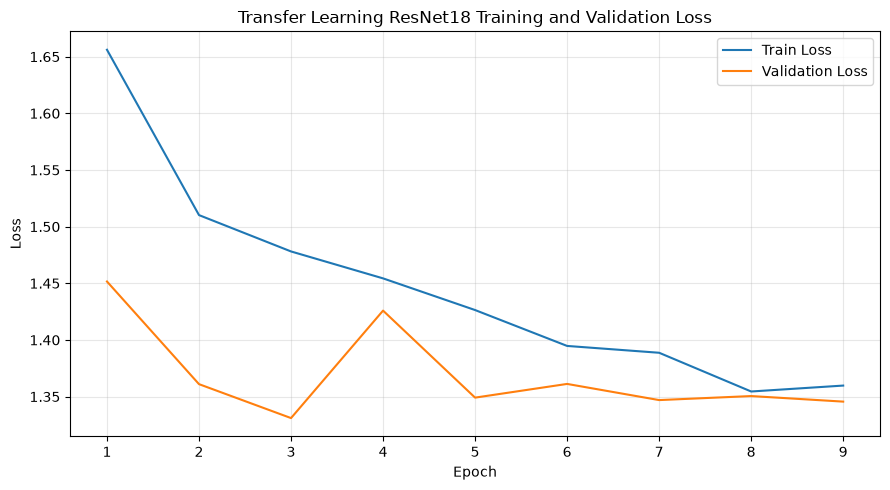

In [20]:
# Plot loss
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning ResNet18 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "transfer_resnet18_loss_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


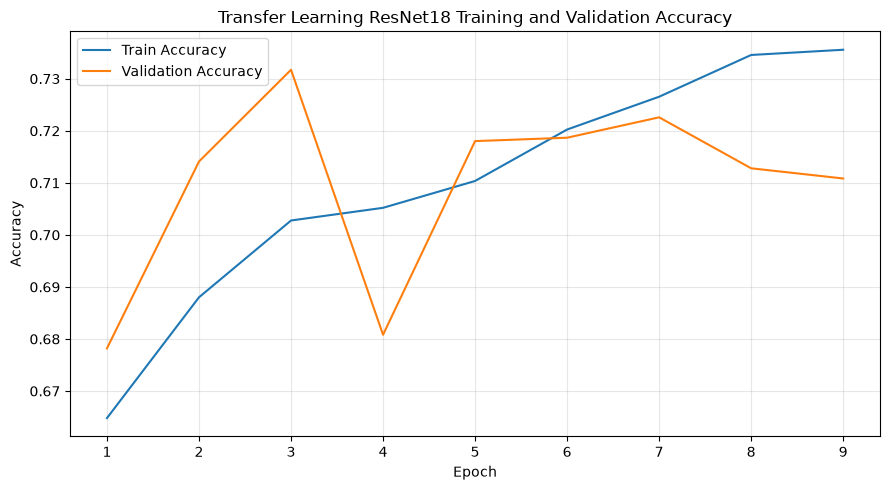

In [21]:
# Plot accuracy
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy",
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning ResNet18 Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "transfer_resnet18_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
